In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar datos
df = pd.read_csv('../Dataset/vehicles.csv')
print(f"Cantidad de filas: {df.shape[0]:,}  -  Cantidad de columnas: {df.shape[1]}")

Cantidad de filas: 426,880  -  Cantidad de columnas: 26


In [5]:
# Descartar columnas inecesariasen el datset
deleteCols = ['id', 'url', 'region_url', 'image_url', 'VIN', 'lat', 'long', 'county', 'description']
df.drop(columns=deleteCols, inplace=True)
print("Columnas restantes:", df.columns.tolist())

Columnas restantes: ['region', 'price', 'year', 'manufacturer', 'model', 'condition', 'cylinders', 'fuel', 'odometer', 'title_status', 'transmission', 'drive', 'size', 'type', 'paint_color', 'state', 'posting_date']


              Cantidad de nulos  Porcentaje
size                     306361       71.77
cylinders                177678       41.62
condition                174104       40.79
drive                    130567       30.59
paint_color              130203       30.50
type                      92858       21.75
manufacturer              17646        4.13
title_status               8242        1.93
model                      5277        1.24
odometer                   4400        1.03
fuel                       3013        0.71
transmission               2556        0.60
year                       1205        0.28
posting_date                 68        0.02


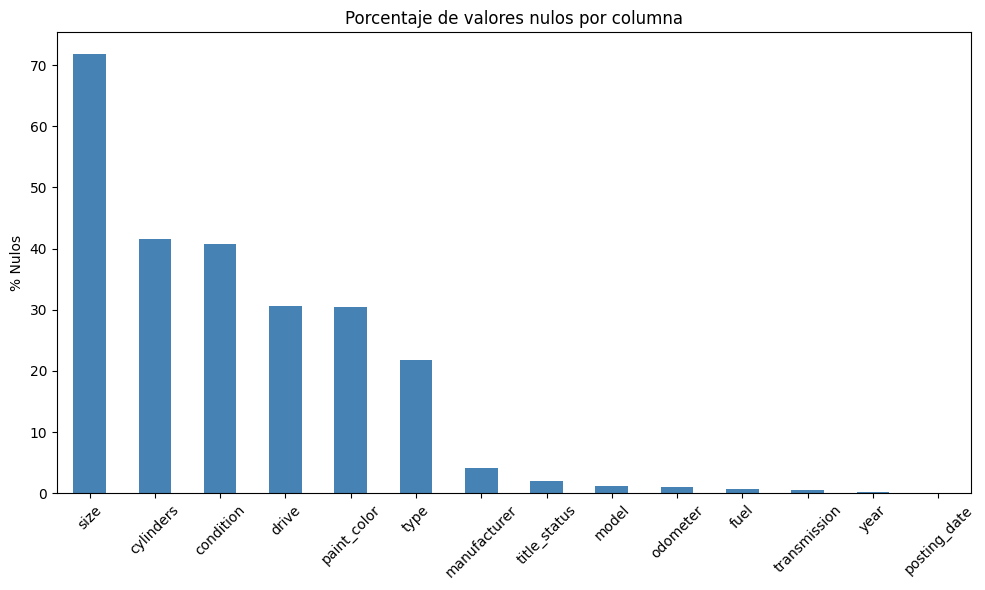

In [6]:
# Análisis de valores nulos
nulos = pd.DataFrame({
    'Cantidad de nulos': df.isnull().sum(),
    'Porcentaje': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('Porcentaje', ascending=False)

print(nulos[nulos['Cantidad de nulos'] > 0])

# Visualización en grafico
plt.figure(figsize=(10, 6))
nulos[nulos['Porcentaje'] > 0]['Porcentaje'].plot(kind='bar', color='steelblue')
plt.title('Porcentaje de valores nulos por columna')
plt.ylabel('% Nulos')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('nulos.png', dpi=150)
plt.show()

Precio - estadísticas:
count    4.268800e+05
mean     7.519903e+04
std      1.218228e+07
min      0.000000e+00
25%      5.900000e+03
50%      1.395000e+04
75%      2.648575e+04
max      3.736929e+09
Name: price, dtype: float64

Filas eliminadas por precio: 42,749


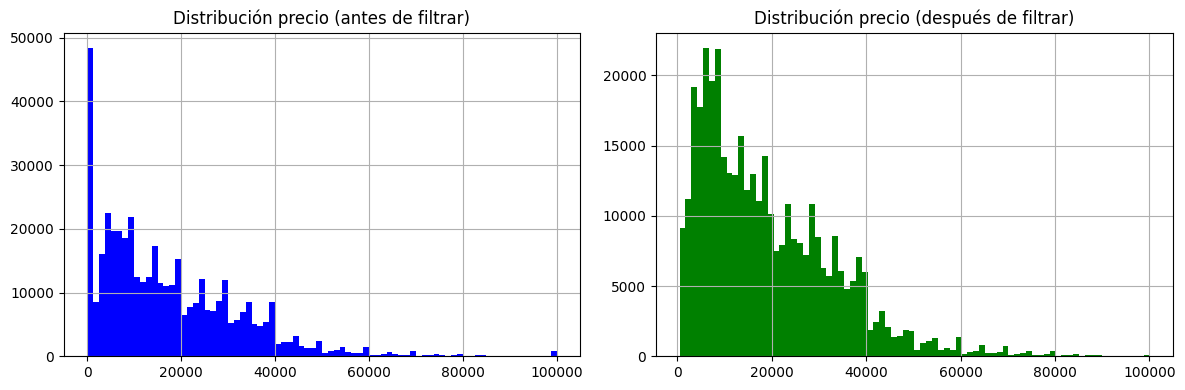

In [7]:
# Detección de outliers del precio
print("Precio - estadísticas:")
print(df['price'].describe())

# Distribución antes de filtrar la columna
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
df['price'].clip(0, 100000).hist(bins=80, color='blue')
plt.title('Distribución precio (antes de filtrar)')
 
# Filtrar el precio entre $500 y $100,000
dfFiltrado = df[(df['price'] >= 500) & (df['price'] <= 100000)].copy()
print(f"\nFilas eliminadas por precio: {len(df) - len(dfFiltrado):,}")

plt.subplot(1, 2, 2)
dfFiltrado['price'].hist(bins=80, color='green')
plt.title('Distribución precio (después de filtrar)')
plt.tight_layout()
plt.savefig('precio_distribucion.png', dpi=150)
plt.show()

In [8]:
# Detección de outliers del odómetro
print("Odómetro - estadísticas:")
print(dfFiltrado['odometer'].describe())

# Filtrar el odómetro entre 0 y 500,000
dfFiltrado = dfFiltrado[(dfFiltrado['odometer'] > 0) & (dfFiltrado['odometer'] < 500000)].copy()
print(f"Filas tras filtrar odómetro: {len(dfFiltrado):,}")

Odómetro - estadísticas:
count    3.820160e+05
mean     9.859866e+04
std      1.920286e+05
min      0.000000e+00
25%      3.837900e+04
50%      8.781450e+04
75%      1.360000e+05
max      1.000000e+07
Name: odometer, dtype: float64
Filas tras filtrar odómetro: 379,771


In [9]:
# Análisis de las columnas de categorias
catCols = ['condition', 'fuel', 'transmission', 'drive', 'type', 'title_status']

for col in catCols:
    print(f"\n--- {col} ---")
    print(dfFiltrado[col].value_counts(dropna=False))


--- condition ---
condition
NaN          143748
good         117908
excellent     90625
like new      19507
fair           6477
new             978
salvage         528
Name: count, dtype: int64

--- fuel ---
fuel
gas         318492
other        27277
diesel       25384
hybrid        4743
NaN           2282
electric      1593
Name: count, dtype: int64

--- transmission ---
transmission
automatic    295150
other         60588
manual        22524
NaN            1509
Name: count, dtype: int64

--- drive ---
drive
4wd    116132
NaN    115453
fwd     94714
rwd     53472
Name: count, dtype: int64

--- type ---
type
NaN            81690
sedan          77176
SUV            67914
pickup         40731
truck          29688
other          19442
coupe          17443
hatchback      15580
wagon           9665
van             7777
convertible     7167
mini-van        4471
offroad          578
bus              449
Name: count, dtype: int64

--- title_status ---
title_status
clean         360300
rebuilt

In [10]:
# Resumen del análisis de calidad
print("---- RESUMEN DEL ANÁLISIS DE CALIDAD ----")
print(f"Filas originales:  {df.shape[0]:,}")
print(f"Filas tras filtrado: {len(dfFiltrado):,}")
print(f"Columnas usadas: {dfFiltrado.shape[1]}")
print("\nNulos restantes:")
print(dfFiltrado.isnull().sum()[dfFiltrado.isnull().sum() > 0])

---- RESUMEN DEL ANÁLISIS DE CALIDAD ----
Filas originales:  426,880
Filas tras filtrado: 379,771
Columnas usadas: 17

Nulos restantes:
year              1097
manufacturer     14690
model             4327
condition       143748
cylinders       154769
fuel              2282
title_status      6479
transmission      1509
drive           115453
size            272658
type             81690
paint_color     109560
dtype: int64
